# Metric Evaluation

Figures for the analysis layer, driven from the eval outputs that run_evaluation.py writes. Sample-level scores are read from merged.csv for the curves / quadrant / embeddings. If the output CSVs aren't present the tables are recomputed on the fly.

Run run_evaluation.py first (per dataset / pooled set)

eval_df = df[df["binder"].astype(str).isin(["0", "1"])].copy()
eval_df["binder"] = eval_df["binder"].astype(int)

design_df = df[df["type"] == "design"].copy()

In [1]:
import pandas as pd

from config.datasets import cfg
from config.paths import RAW_DATA_DIR, EVALUATION_DIR, METRIC_YAML
from config.analysis import COLORS_MAP
from preprocessing.align import load_metric_directions
from analysis.distributions import get_numeric_metrics
from analysis.evaluation import (
    calculate_all_metrics, compute_auroc_pvalue, cliffs_delta, cohens_d,
    spearman_correlation, label_metrics, pca_embedding, umap_embedding,
    plot_top_metrics_bar, plot_roc_curves, plot_pr_curves, plot_precision_ranking,
    plot_metric_comparison_grid, plot_quadrant, plot_embedding, plot_spearman_heatmap,
)

In [2]:
base = RAW_DATA_DIR / cfg.name
eval_dir = EVALUATION_DIR / cfg.name          # where run_evaluation.py wrote the tables

# Labeled evaluation split only (binder in {0,1}); designs ("?") are excluded.
# eval.csv is written by prep for both single datasets and pooled sets.
merged_path = base / "merged.csv"  # df with eval + designs
df = pd.read_csv(merged_path)
#eval_df = df[df["binder"].astype(str).isin(["0", "1"])].copy()
#eval_df["binder"] = eval_df["binder"].astype(int)

#design_df = df[df["binder"] == "?"].copy()

design_df = base / "design.csv"

eval_path = base / "eval.csv"
eval_df = pd.read_csv(eval_path) if eval_path.exists() else split_eval_design(df)[0]

In [3]:
metrics = get_numeric_metrics(eval_df)
directions = load_metric_directions(METRIC_YAML)

# Prefer the run_evaluation.py outputs; recompute only if a table is missing.
def load_or_compute(name, fn):
    p = eval_dir / name
    return pd.read_csv(p) if p.exists() else fn()

rankings = load_or_compute("rankings.csv", lambda: calculate_all_metrics(eval_df, metrics, directions))
rankings.head(15)

,metric,raw_roc,aligned_roc,pr_auc,f1,precision,recall,opt_threshold,opt_threshold_raw,direction,note
0,cf_ipsae,0.6933,0.6933,0.7389,0.6780,0.7407,0.6250,0.7251,0.7251,1,NaN
1,cf_lis,0.6715,0.6715,0.7186,0.6667,0.5000,1.0000,0.2466,0.2466,1,NaN
2,pred_lddt,0.6669,0.6669,0.7153,0.6714,0.6184,0.7344,0.8635,0.8635,1,NaN
3,cf_pae,0.3392,0.6608,0.7133,0.6667,0.5000,1.0000,-4.9377,4.9377,-1,NaN
4,pred_ilddt,0.6543,0.6543,0.7038,0.6632,0.4961,1.0000,0.1270,0.1270,1,NaN
5,af3_ipsae,0.6552,0.6552,0.6927,0.6821,0.5413,0.9219,0.0852,0.0852,1,NaN
6,cf_iplddt,0.6536,0.6536,0.6888,0.6632,0.4961,1.0000,0.6955,0.6955,1,NaN
7,cf_pdockq2,0.6495,0.6495,0.6806,0.6702,0.5039,1.0000,0.0842,0.0842,1,NaN
8,af3_pae,0.3487,0.6513,0.6739,0.6632,0.4961,1.0000,-5.5550,5.5550,-1,NaN
9,esmfold2_pae,0.3916,0.6084,0.6602,0.6702,0.5039,1.0000,-7.6135,7.6135,-1,NaN


## Rankings

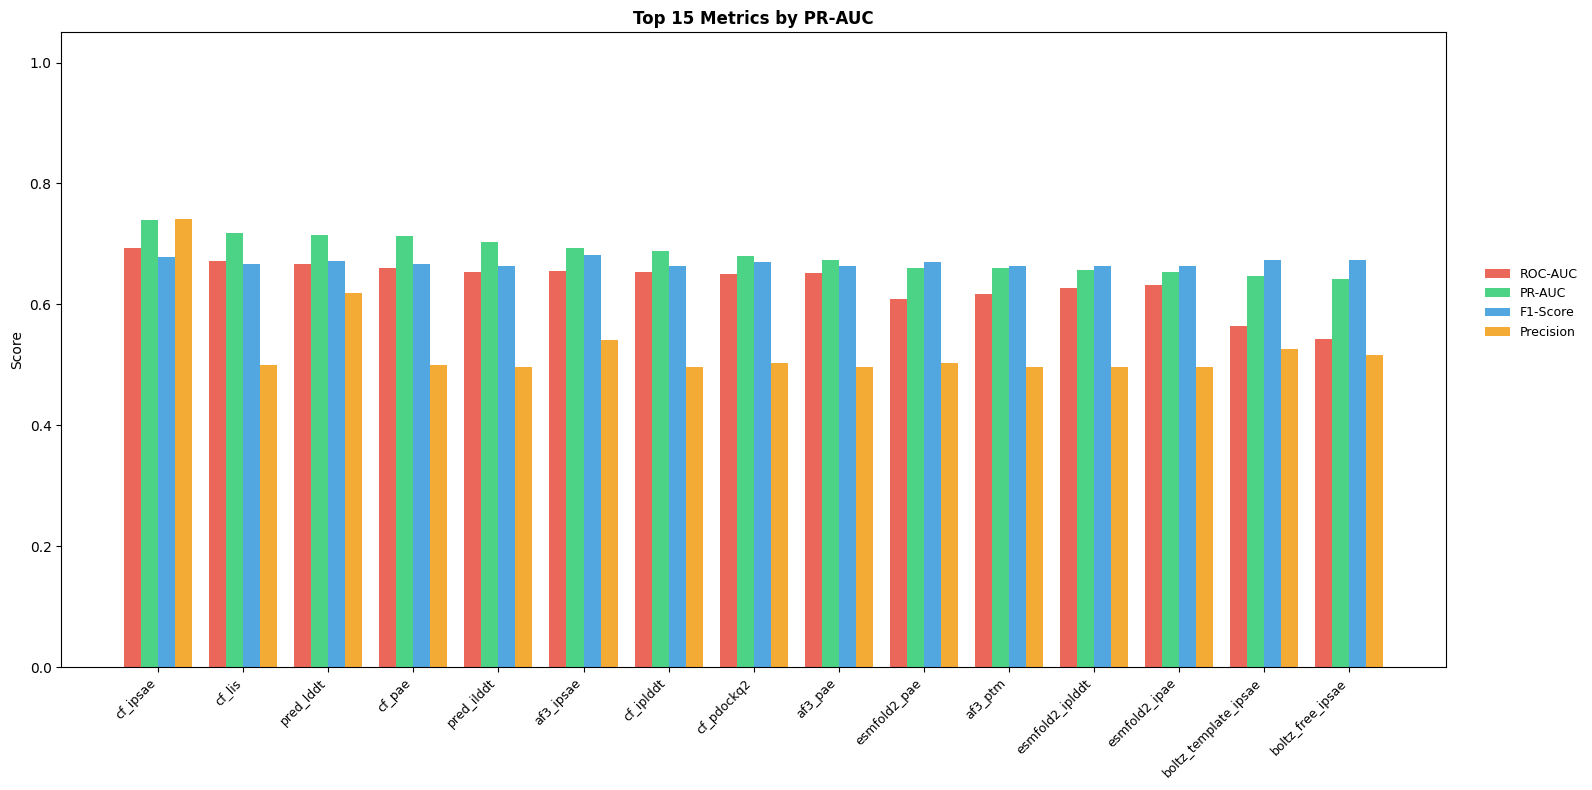

In [4]:
plot_top_metrics_bar(rankings, show=True)

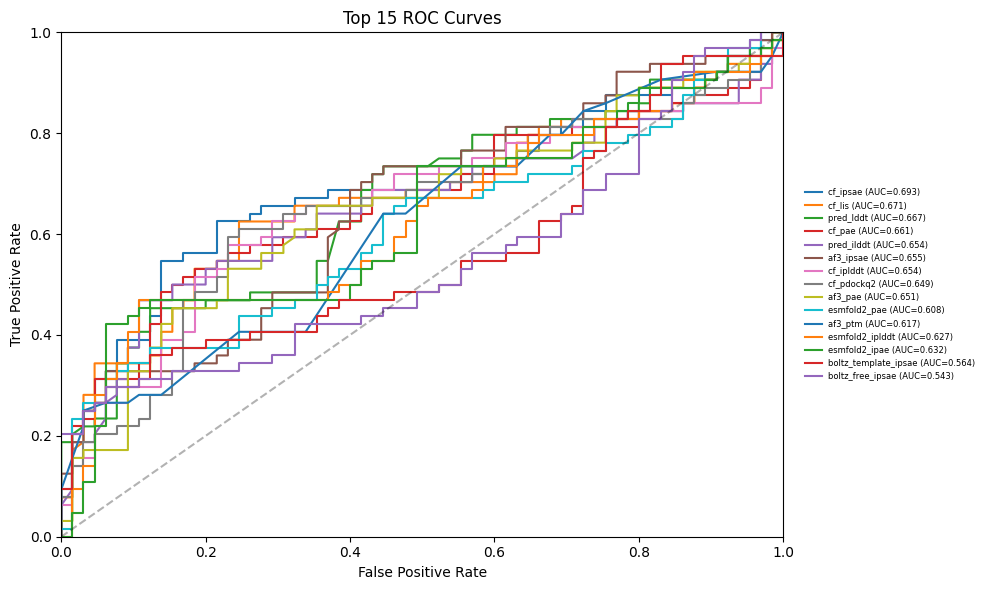

In [5]:
plot_roc_curves(eval_df, rankings, directions, show=True)

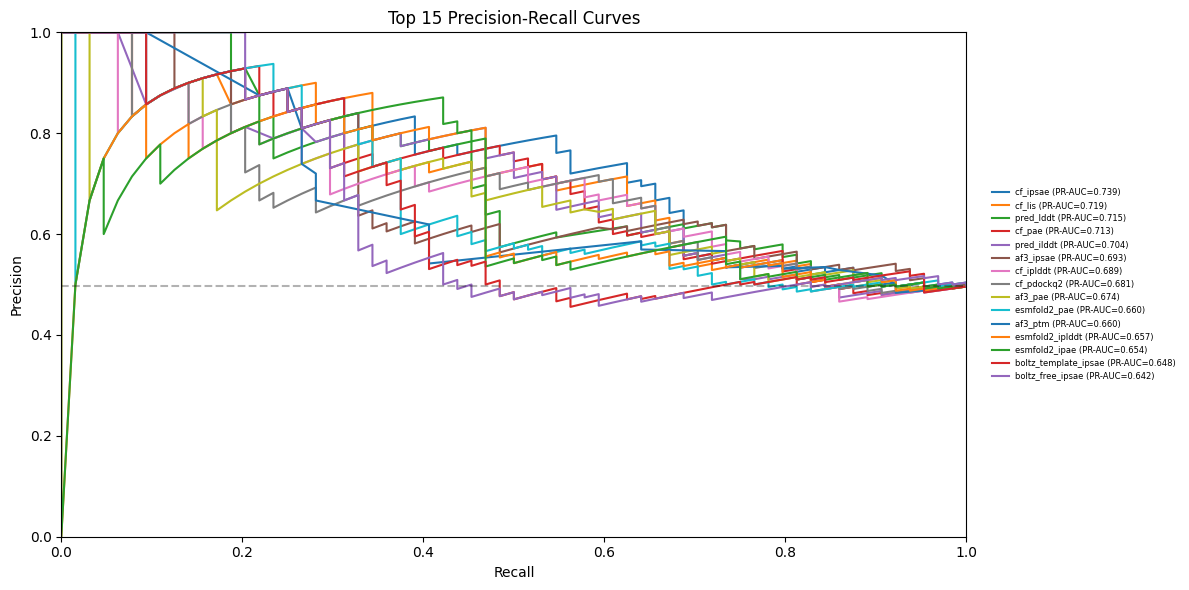

In [6]:
plot_pr_curves(eval_df, rankings, directions, show=True)

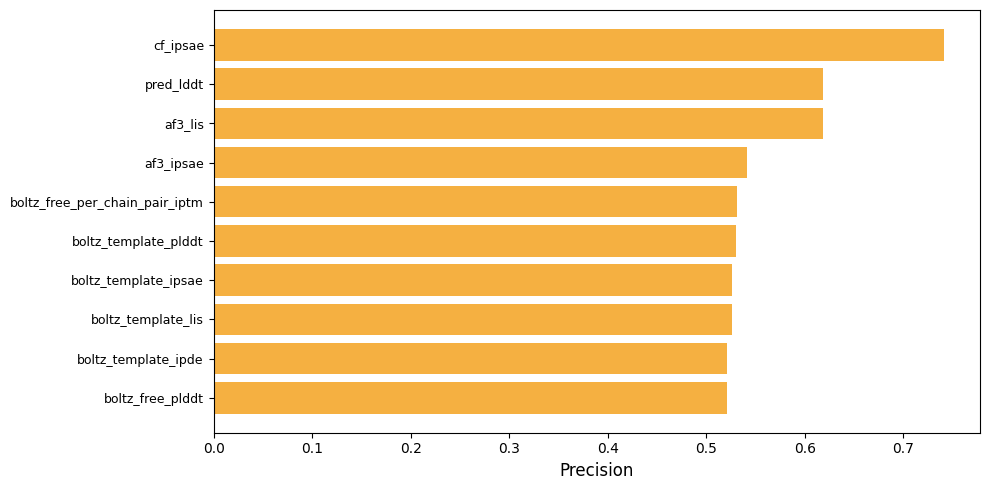

In [7]:
plot_precision_ranking(rankings, show=True)

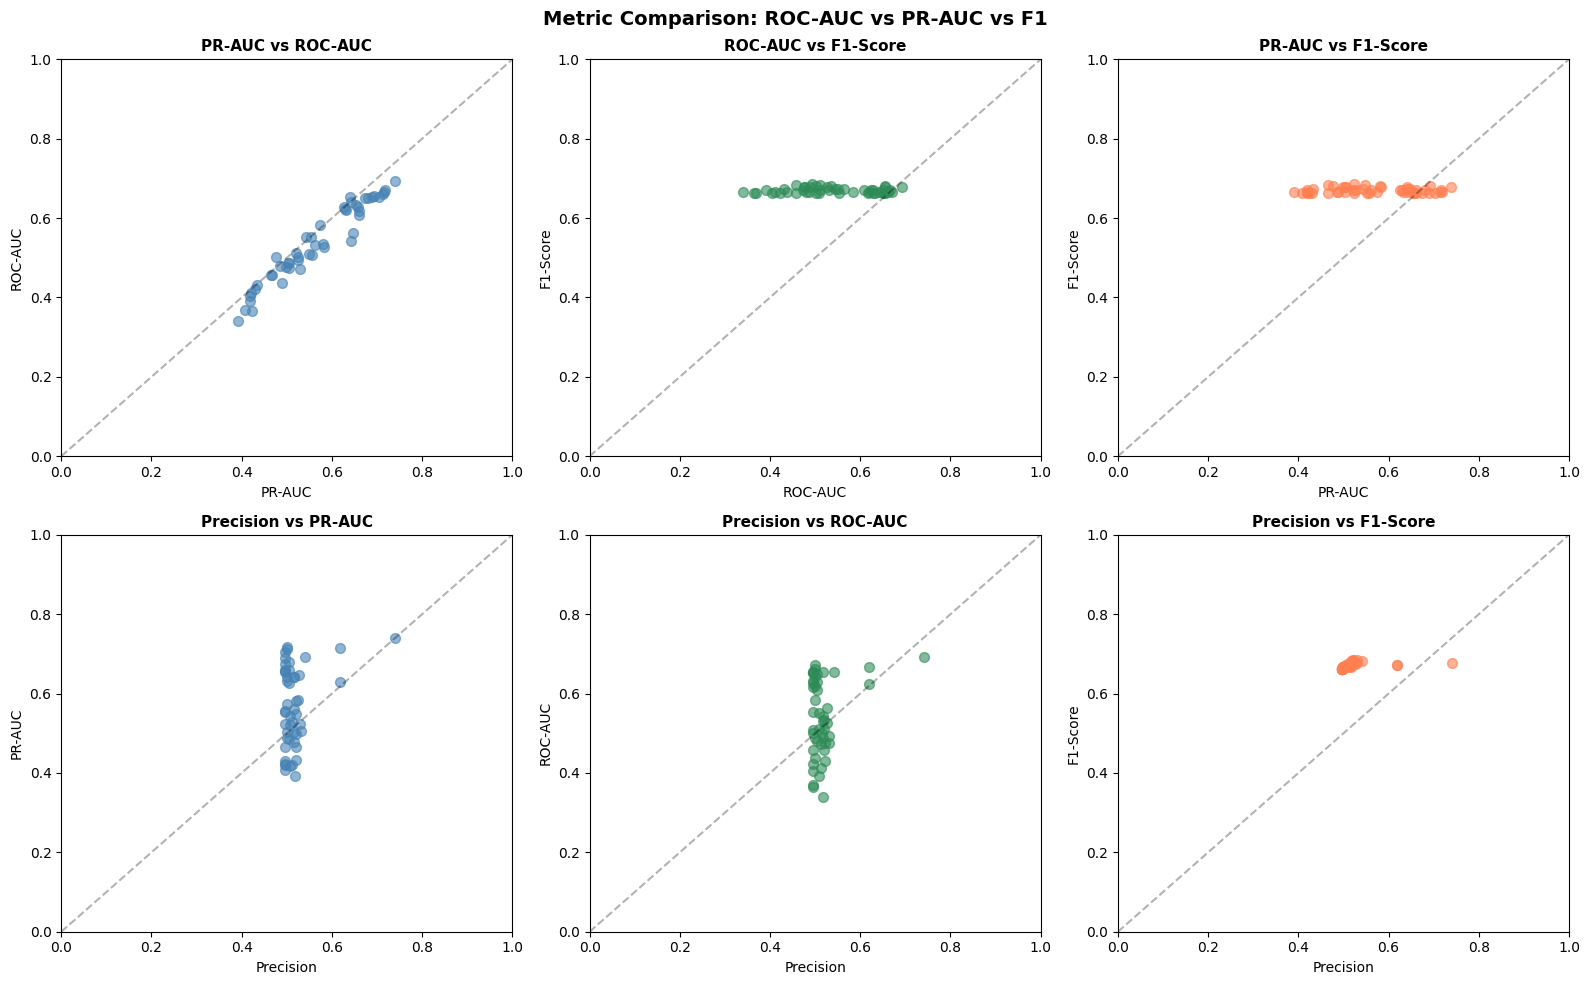

In [8]:
plot_metric_comparison_grid(rankings, show=True)

## Quadrant (top-2 metrics)

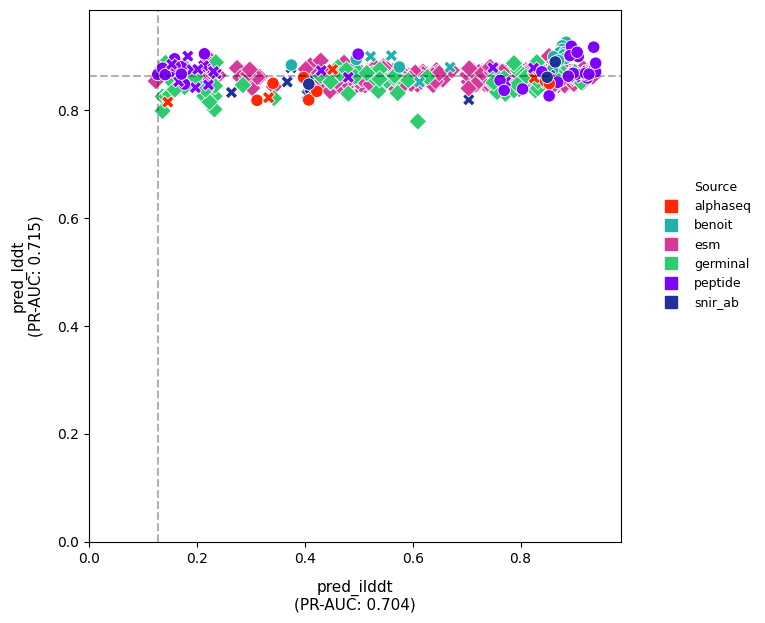

,metric,raw_roc,aligned_roc,pr_auc,f1,precision,recall,opt_threshold,opt_threshold_raw,direction,note
0,cf_ipsae,0.6933,0.6933,0.7389,0.6780,0.7407,0.6250,0.7251,0.7251,1,NaN
1,cf_lis,0.6715,0.6715,0.7186,0.6667,0.5000,1.0000,0.2466,0.2466,1,NaN
2,pred_lddt,0.6669,0.6669,0.7153,0.6714,0.6184,0.7344,0.8635,0.8635,1,NaN
3,cf_pae,0.3392,0.6608,0.7133,0.6667,0.5000,1.0000,-4.9377,4.9377,-1,NaN
4,pred_ilddt,0.6543,0.6543,0.7038,0.6632,0.4961,1.0000,0.1270,0.1270,1,NaN
5,af3_ipsae,0.6552,0.6552,0.6927,0.6821,0.5413,0.9219,0.0852,0.0852,1,NaN
6,cf_iplddt,0.6536,0.6536,0.6888,0.6632,0.4961,1.0000,0.6955,0.6955,1,NaN
7,cf_pdockq2,0.6495,0.6495,0.6806,0.6702,0.5039,1.0000,0.0842,0.0842,1,NaN
8,af3_pae,0.3487,0.6513,0.6739,0.6632,0.4961,1.0000,-5.5550,5.5550,-1,NaN
9,esmfold2_pae,0.3916,0.6084,0.6602,0.6702,0.5039,1.0000,-7.6135,7.6135,-1,NaN


In [9]:
plot_quadrant(df, rankings, COLORS_MAP, show=True)
rankings.head(15)

### Interactive quadrant (Plotly)

In [10]:
import plotly.graph_objects as go

marker_map_ply = {0: "diamond-x", "0": "diamond-x", 1: "circle", "1": "circle", "?": "square" }
alpha_map = {"dms": 0.4, "original": 0.4, "design": 1.0, "alanine_scan": 0.4}

top = rankings.sort_values("pr_auc", ascending=False).head(20)
m1i, m2i = top.iloc[1], top.iloc[2]
m1, m2 = m1i["metric"], m2i["metric"]
t1, t2 = m1i["opt_threshold_raw"], m2i["opt_threshold_raw"]

pdf = df.groupby(["source", "sample", "type", "binder"])[[m1, m2]].agg(["mean", "std"]).reset_index()
pdf.columns = [f"{c[0]}_{c[1]}" if c[1] else c[0] for c in pdf.columns]

fig = go.Figure()
for t, tdf in pdf.groupby("type"):
    op = alpha_map.get(t, 1.0)
    for (source, binder), sub in tdf.groupby(["source", "binder"]):
        fig.add_trace(go.Scatter(
            x=sub[f"{m1}_mean"], y=sub[f"{m2}_mean"], mode="markers",
            marker=dict(color=COLORS_MAP.get(source), symbol=marker_map_ply[binder], size=8, opacity=op),
            name=f"{source} | {t} | binder={binder}", text=sub["sample"],
            hovertemplate="<b>%{text}</b><br>x=%{x:.3f}<br>y=%{y:.3f}<extra></extra>",
        ))
fig.add_vline(x=t1, line_dash="dash", line_color="black", opacity=0.3)
fig.add_hline(y=t2, line_dash="dash", line_color="black", opacity=0.3)
fig.update_layout(width=900, height=700, plot_bgcolor="white", title=f"{m1} vs {m2}", xaxis_title=m1, yaxis_title=m2)
fig.show()

## Top separators (from distinct metrics families)

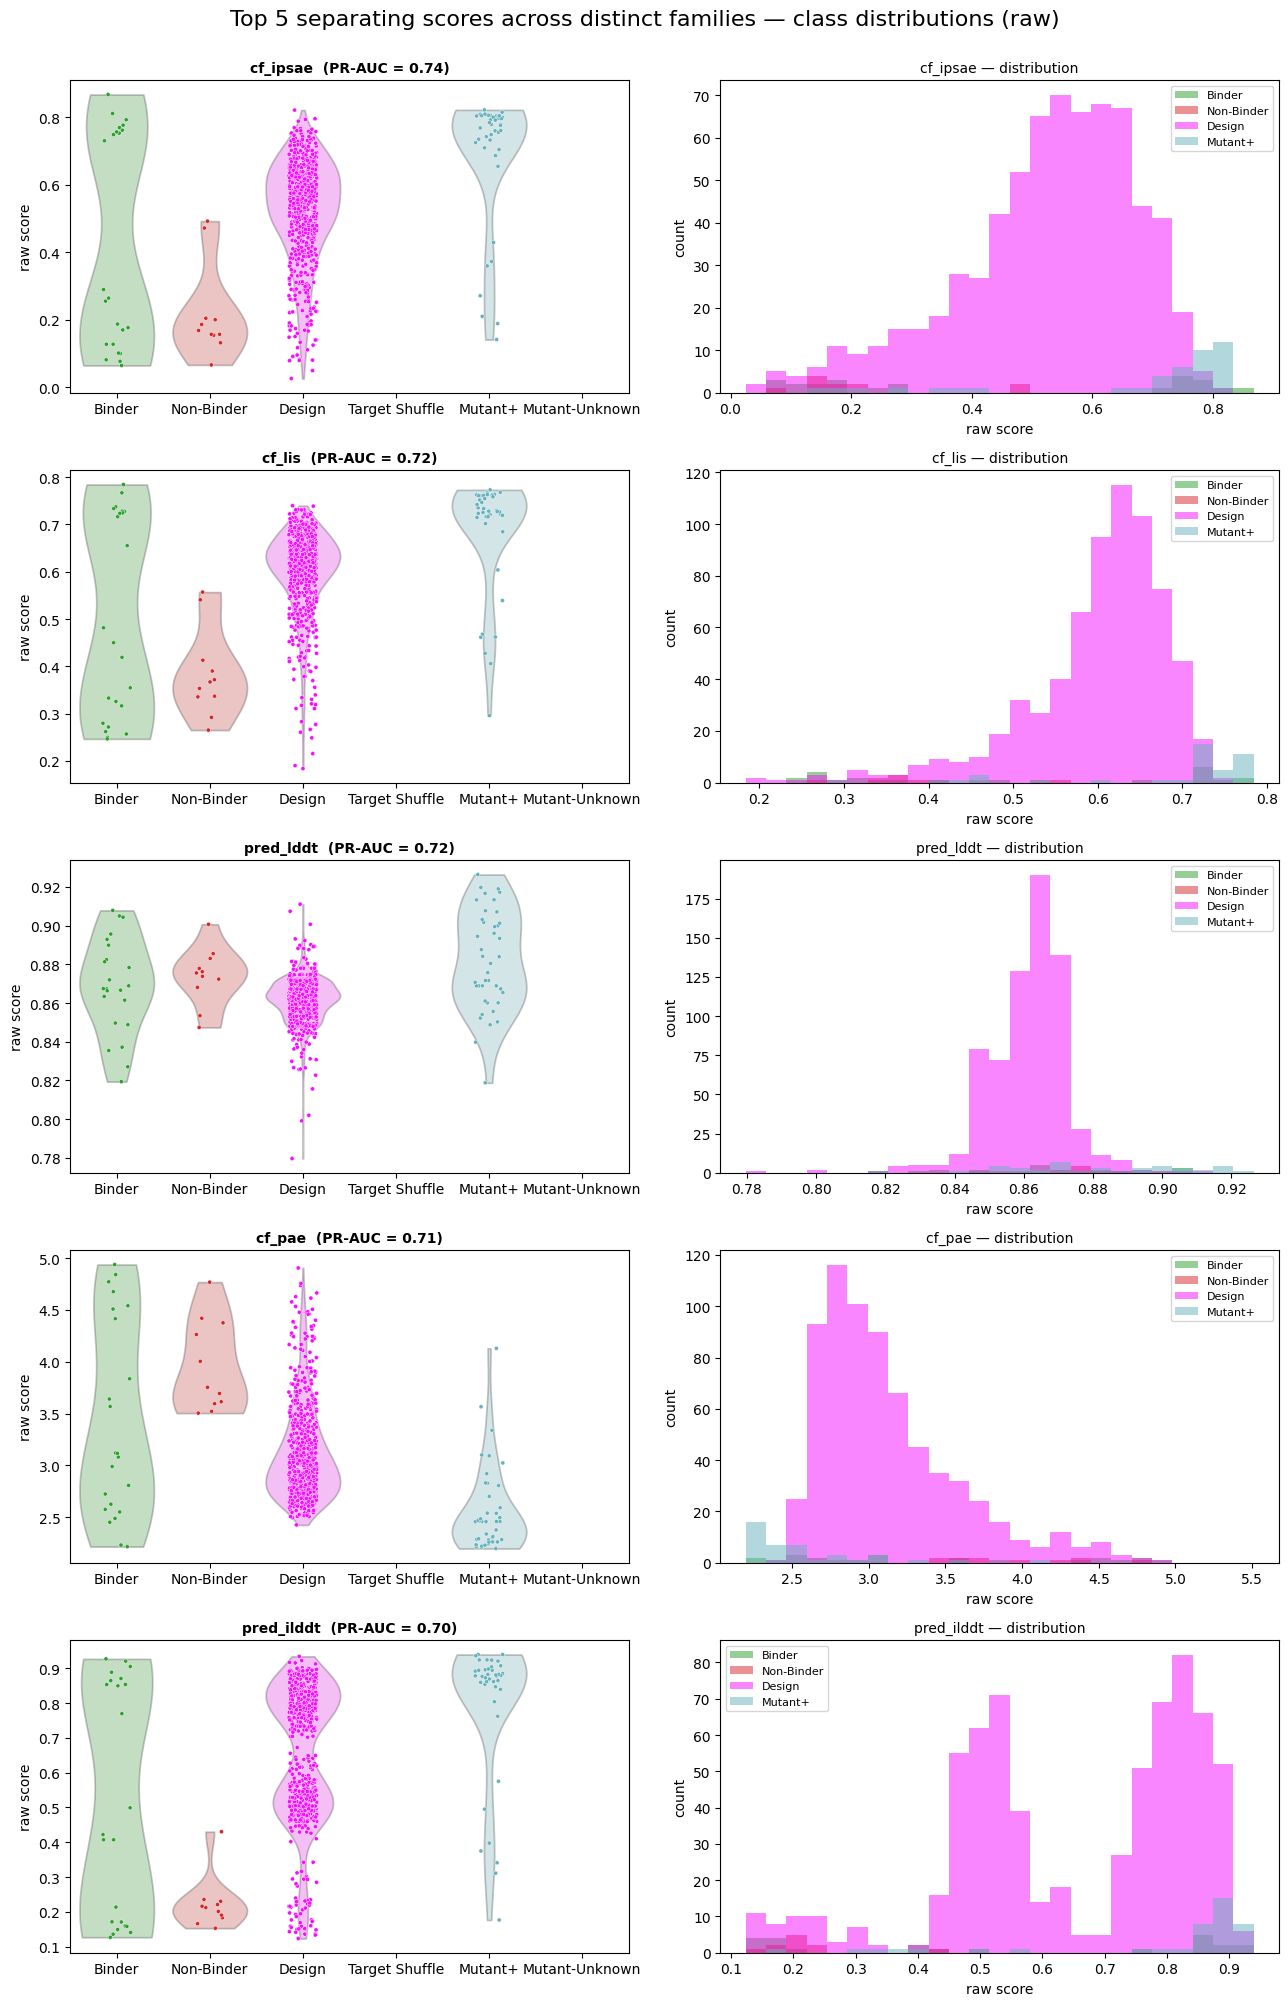

In [11]:
from analysis.evaluation.metrics import load_metric_families
from analysis.evaluation import top_metrics_distinct_family, plot_class_distributions

# Top separating metrics, one per YAML family
families = load_metric_families(METRIC_YAML)
top_fam = top_metrics_distinct_family(rankings, families, top_n=5)

# Distributions include the Design class, so plot the full merged table
# (the eval df above is label-only and excludes designs).
plot_class_distributions(
    df, rankings, metrics=top_fam["metric"].tolist(),
    save_path=eval_dir / "top5_family_distinct_distributions.png", show=True,
)

#df.head(30)

## Effect sizes

In [12]:
cliff = load_or_compute("cliffs_delta.csv", lambda: cliffs_delta(df, metrics, directions))
auroc = load_or_compute("auroc_pvalue.csv", lambda: compute_auroc_pvalue(df, metrics, directions))
cohen = load_or_compute("cohens_d.csv", lambda: cohens_d(df, metrics, directions))
cliff.head(15)

,metric,cliffs_delta
0,cf_ipsae,0.3865
1,cf_lis,0.3430
2,pred_lddt,0.3339
3,cf_pae,0.3216
4,boltz_free_ptm,-0.3197
5,af3_ipsae,0.3103
6,pred_ilddt,0.3087
7,af3_iplddt,0.3079
8,cf_iplddt,0.3072
9,af3_pae,0.3026


## Redundancy

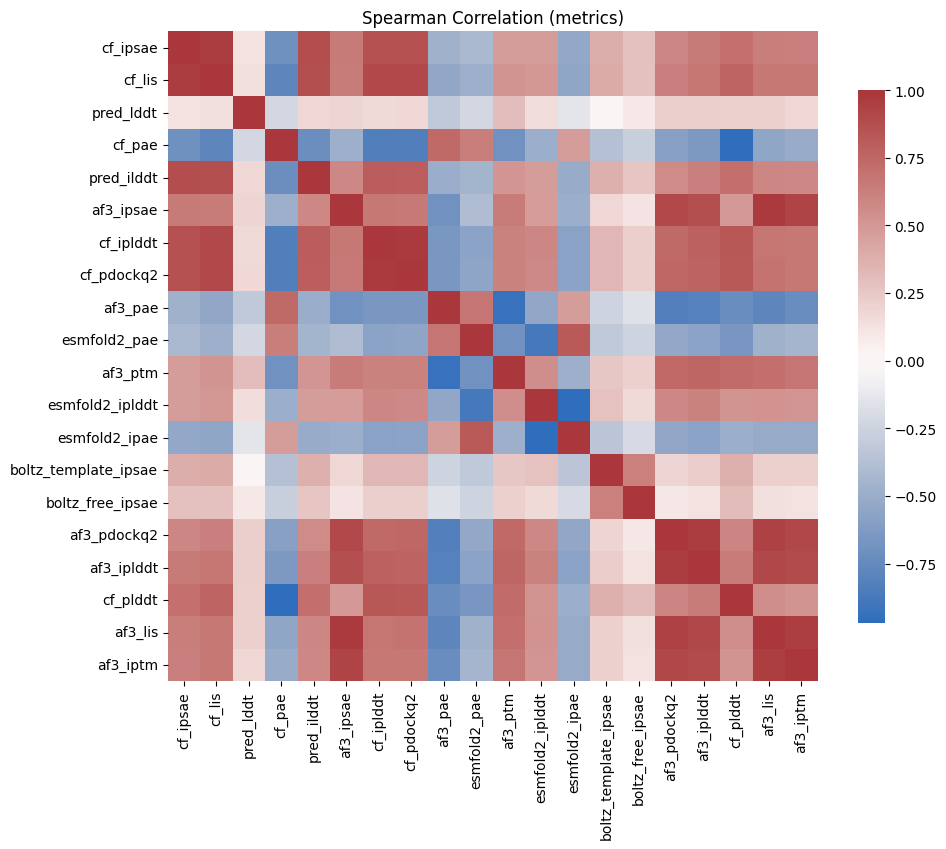

In [13]:
top20 = rankings.head(20)["metric"].tolist()
plot_spearman_heatmap(spearman_correlation(df, top20), show=True)

PC1 88.6%  PC2 7.9%


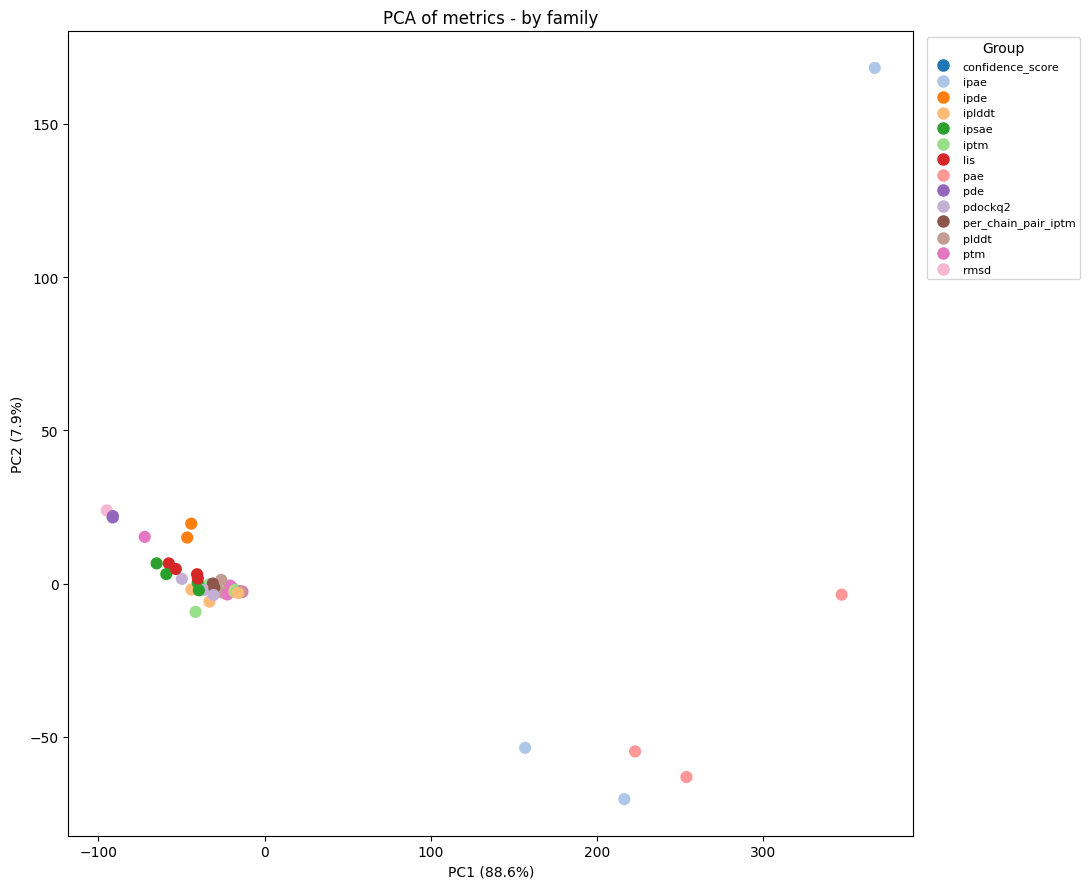

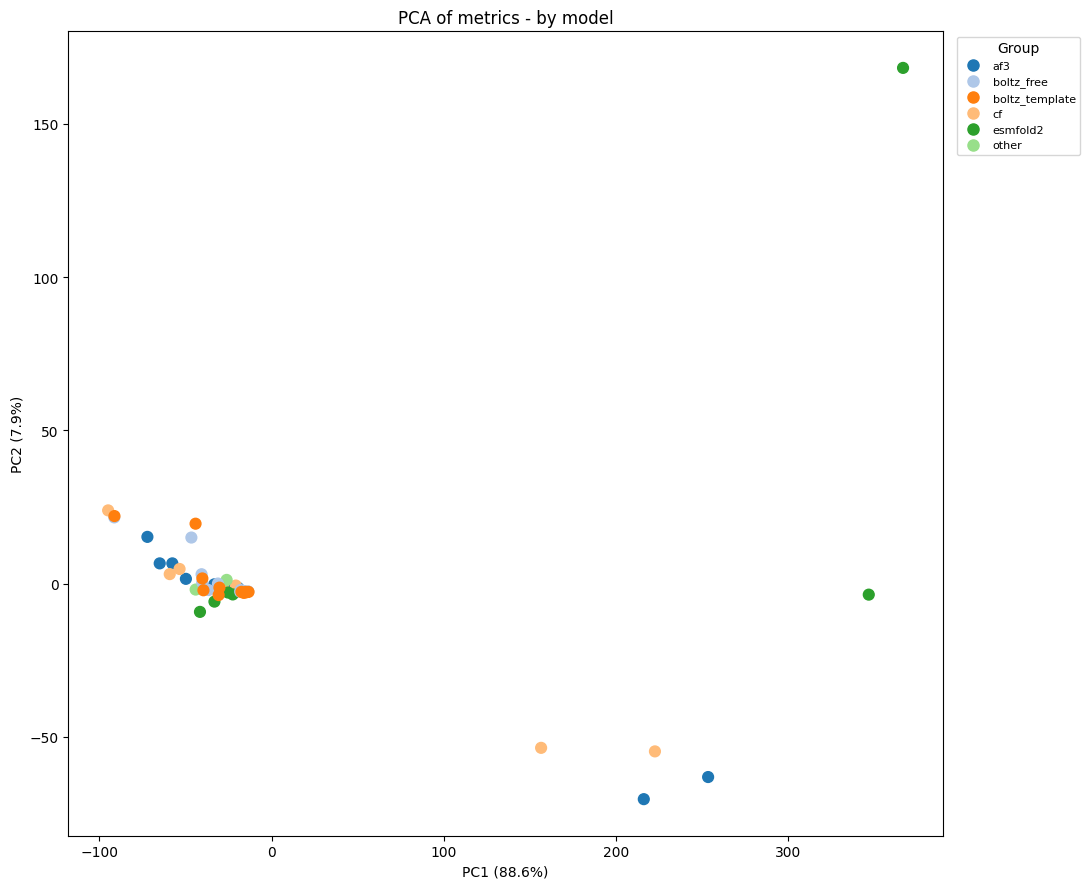

In [14]:
emb_pca, names, var = pca_embedding(df)
print(f"PC1 {var[0]:.1%}  PC2 {var[1]:.1%}")
plot_embedding(emb_pca, names, label_metrics(names, "family"),
    title="PCA of metrics - by family", xlabel=f"PC1 ({var[0]:.1%})", ylabel=f"PC2 ({var[1]:.1%})", show=True)
plot_embedding(emb_pca, names, label_metrics(names, "model"),
    title="PCA of metrics - by model", xlabel=f"PC1 ({var[0]:.1%})", ylabel=f"PC2 ({var[1]:.1%})", show=True)

/scicore/home/schwede/barta0000/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/scicore/home/schwede/barta0000/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


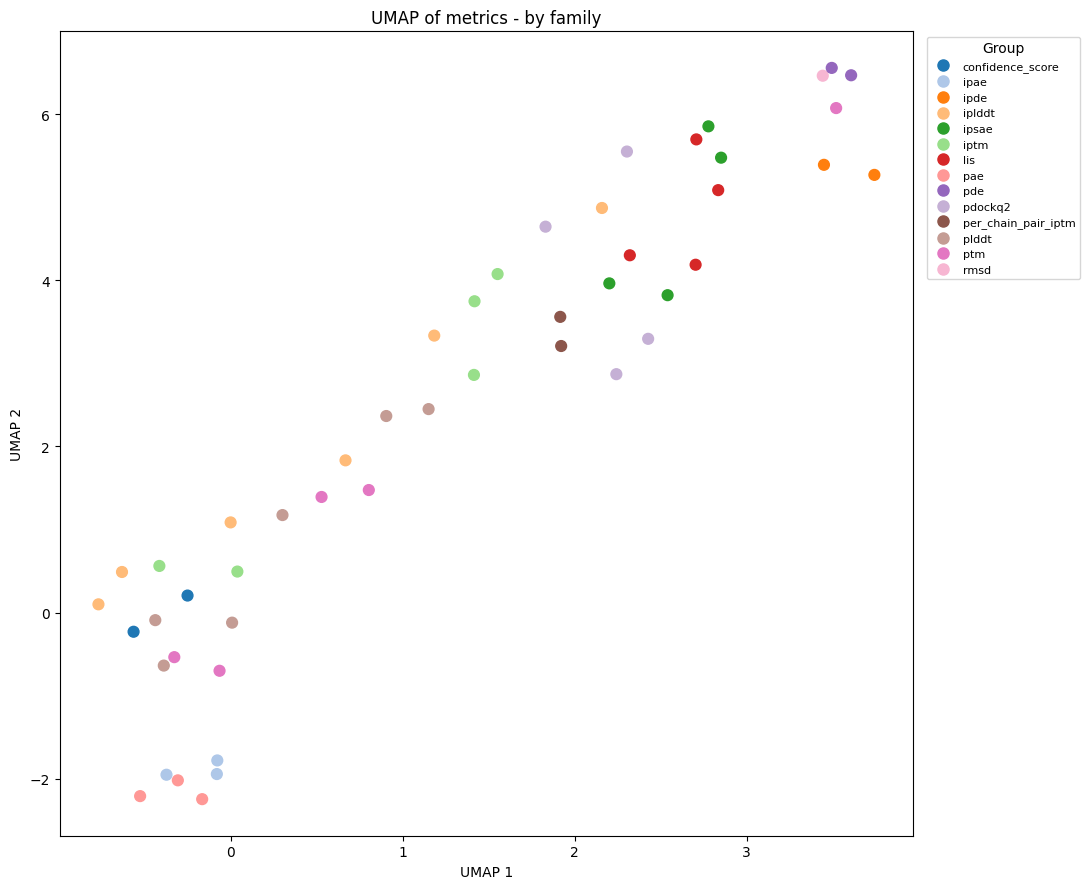

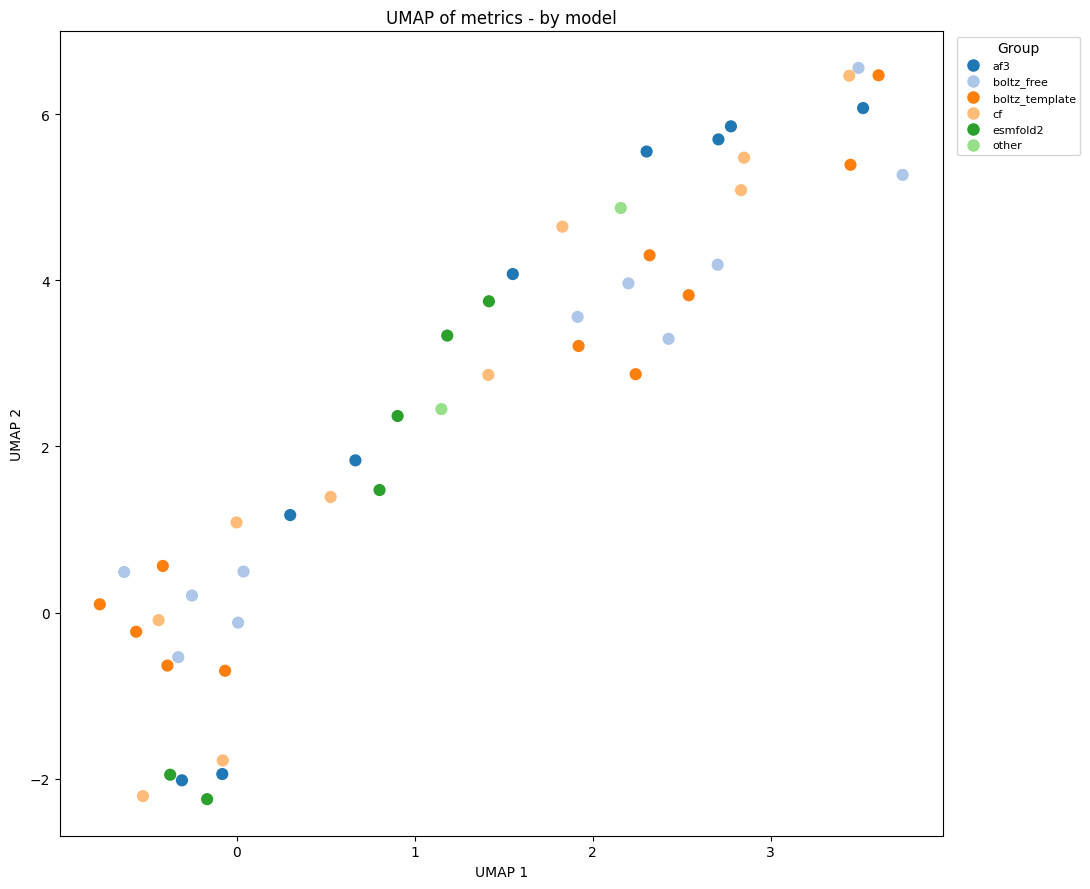

In [15]:
emb_umap, names = umap_embedding(df)
plot_embedding(emb_umap, names, label_metrics(names, "family"),
    title="UMAP of metrics - by family", xlabel="UMAP 1", ylabel="UMAP 2", show=True)
plot_embedding(emb_umap, names, label_metrics(names, "model"),
    title="UMAP of metrics - by model", xlabel="UMAP 1", ylabel="UMAP 2", show=True)

## Per-dataset breakdown (pooled sets)

For a pooled set, run_evaluation.py also writes rankings by dataset. This compares each member dataset's PR-AUC on the top pooled metrics .

/scratch/ipykernel_3152774/729884400.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


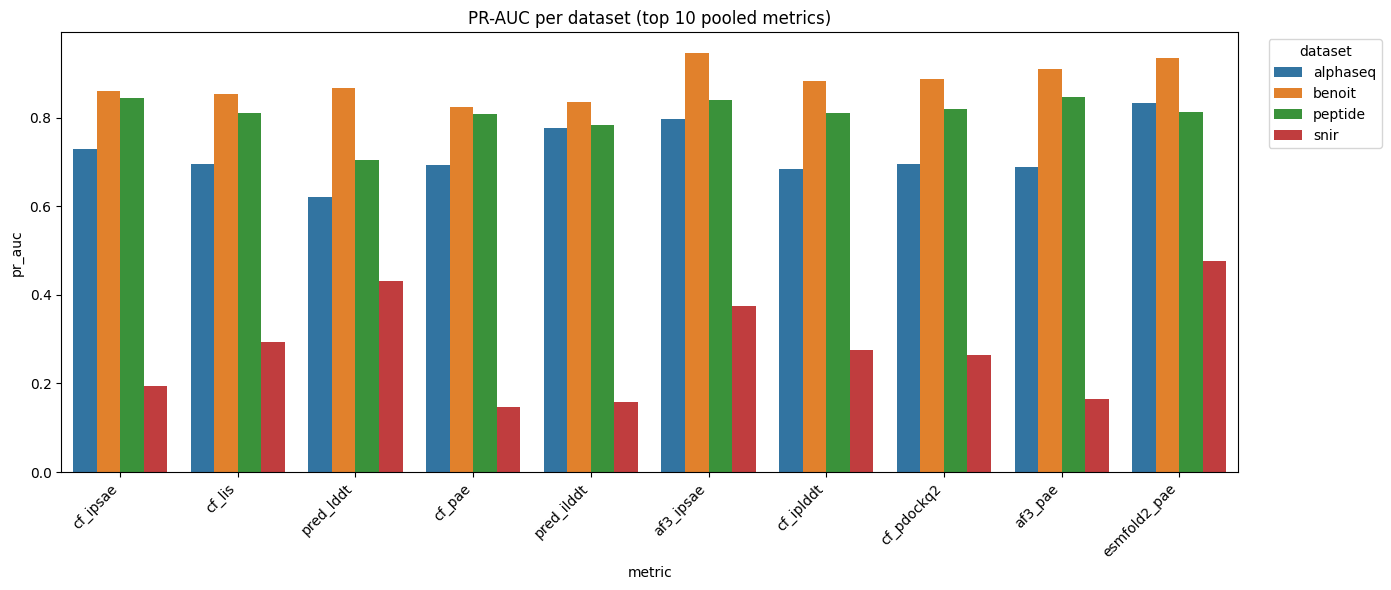

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

p = eval_dir / "rankings_by_dataset.csv"
if p.exists():
    by_ds = pd.read_csv(p)
    top_metrics = rankings.head(10)["metric"].tolist()
    sub = by_ds[by_ds["metric"].isin(top_metrics)]
    fig, ax = plt.subplots(figsize=(14, 6))
    sns.barplot(data=sub, x="metric", y="pr_auc", hue="dataset", order=top_metrics, ax=ax)
    ax.set_title("PR-AUC per dataset (top 10 pooled metrics)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(title="dataset", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout(); plt.show()
else:
    print("No per-dataset breakdown (single dataset, or run_evaluation not run on a set).")